In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [28]:
def audit_qualite(df):
    print("Forme : ")
    print(df.shape)
    print("\n Aperçu dataset : ")
    print(df.head())
    print("\n Infos dataset : ")
    print(df.info())
    print("\n Valeurs nulles")
    print(df.isnull().sum())
 
    print("\n Doublons :", df.duplicated().sum())
    
    print("Répartition de no-show")
    counts = df["No-show"].value_counts()
    percentages = df["No-show"].value_counts(normalize=True) * 100
    repartition = pd.DataFrame({
        "Effectif": counts,
        "Pourcentage (%)": percentages.round(2)
        })

    print(repartition)

def nettoyage(df, columns):
    df_clean = df.copy()
    df_clean = df_clean.drop(
        columns=columns
    )
    df_clean["ScheduledDay"] = pd.to_datetime(df_clean["ScheduledDay"])
    df_clean["AppointmentDay"] = pd.to_datetime(df_clean["AppointmentDay"])
 
    df_clean["waiting_days"] = (
        df_clean["AppointmentDay"] - df_clean["ScheduledDay"]
    ).dt.days

    df_clean = df_clean.drop(columns=["ScheduledDay", "AppointmentDay", "Neighbourhood"])

    df_clean["No-show"] = df_clean["No-show"].map({
        "No": 0,
        "Yes": 1
    })
    df_clean["Gender"] = df_clean["Gender"].map({
        "F": 0,
        "M": 1
    })

    return df_clean


def split_train_val_test(df_clean, cible):
    test_size=0.2
    val_size=0.2
    random_state=42

    y = df_clean[cible]
    X = df_clean.drop(columns=[cible])
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    val_ratio_adjusted = val_size / (1 - test_size)

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=val_ratio_adjusted,
        random_state=random_state,
        stratify=y_train_val
    )

    print(
        f"Train : {X_train.shape} | "
        f"Val : {X_val.shape} | "
        f"Test : {X_test.shape}"
    )

    print("\nDistribution cible (en %) :")
    for name, y_part in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
        print(
            f"{name}:\n{(y_part.value_counts(normalize=True) * 100).round(2)}\n"
        )

    return X_train, X_val, X_test, y_train, y_val, y_test


def evaluer_modele(modele, X_train, y_train, X_test, y_test):
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    return {
        "accuracy": f"{accuracy_score(y_test, y_pred)*100:.2f}%",
        "recall": f"{recall_score(y_test, y_pred)*100:.2f}%",
        "precision": f"{precision_score(y_test, y_pred)*100:.2f}%",
        "f1": f"{f1_score(y_test, y_pred)*100:.2f}%",
    }

In [29]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, recall_score, precision_score
import matplotlib.pyplot as plt


1.Chargement

2.Audit
Forme : 
(110527, 14)

 Aperçu dataset : 
      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   

   Diabetes  Alcoholism  Handcap  SMS_received No-show  
0         0           0       

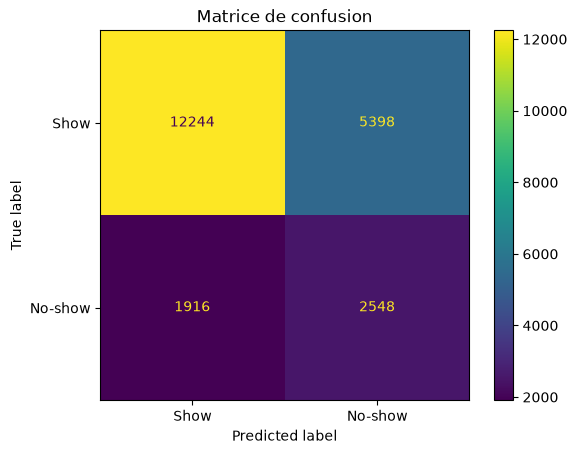


 6. Monter l'Arène

 Évaluation Logistic Regression ....

 Évaluation Random Forest ....

 Évaluation Gradient Boosting ....
                    accuracy  recall precision      f1
Gradient Boosting     79.81%   0.43%    51.35%   0.84%
Random Forest         76.17%  19.87%    34.42%  25.20%
Logistic Regression   66.91%  57.08%    32.07%  41.06%


In [30]:
print("\n1.Chargement")
df_medical = pd.read_csv("KaggleV2-May-2016.csv")
colonnes_inutiles = ["PatientId", "AppointmentID"]
print("\n2.Audit")
audit_qualite(df_medical)
print("\n3.Nettoyage des données")

df_medical_clean = nettoyage(df_medical, colonnes_inutiles)

print(df_medical_clean.head())
print(df_medical_clean.info())

print("\n4. Split")
X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(df_medical_clean, 'No-show')

print("\n 5. 1er algo entrainé")
lr = make_pipeline(StandardScaler(), 
                       LogisticRegression(max_iter=5000, class_weight="balanced"))
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test) 

print(f"Accuracy : {accuracy_score(y_test, y_pred):.2%}")

print("=== Classification report ===")
print(classification_report(y_test, y_pred, target_names=["Show", "No-show"]))

print("=== Confusion matrix ===")
cm = confusion_matrix(y_test, y_pred)

cmDisplay = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Show", "No-show"]
    )
cmDisplay.plot()
plt.title(f"Matrice de confusion")
plt.show()

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

 
rf.fit(X_train, y_train)

gb = GradientBoostingClassifier()
 
gb.fit(X_train, y_train)


models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}


print("\n 6. Monter l'Arène")
results = {}
for name, model in models.items():
    print("\n Évaluation", name, "....")
    result = evaluer_modele(model,  X_train, y_train, X_test, y_test)
    results[name] = result
df_results = pd.DataFrame(results).T
df_results = df_results.sort_values(
    by=["accuracy", "recall", "precision"],
    ascending=[False, False, False]
)
print(df_results)

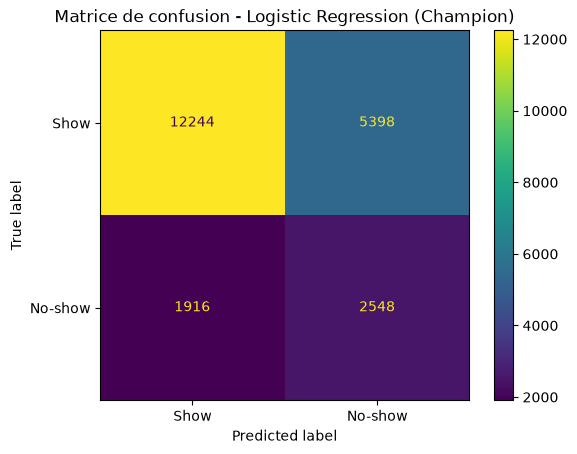

In [33]:
best_model = lr
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

cmDisplay = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Show", "No-show"]
)
cmDisplay.plot()
plt.title("Matrice de confusion - Logistic Regression (Champion)")
plt.show()